# European Car Market Analysis 2012-2023

## Objective
Analysis of changes in the European passenger car market structure, segment trends, and the relationship between bestselling models and overall market evolution.


## 1. Project overview
### Research questions

- How has the structure of the European passenger car market changed between 2012 and 2023?
- Which vehicle segments gained or lost market share over time?
- Do bestselling models reflect overall market trends?
- How has the increasing popularity of SUVs affected the bestselling car landscape?

### Scope and data sources

The analysis covers European passenger car sales between 2012 and 2023.

Datasets used:
- Car model sales data
- Vehicle model information (generation, segment)
- European market segment sales data

Sources:
- **S&P Global Mobility, published by ACEA** – European passenger car sales by market segment
- **Best-selling-cars.com** – annual bestselling car models and sales volumes
- **Coches.com** – bestselling car sales data for 2020
- **Wikipedia** – vehicle generations and segment classification

### Tools
- Python,
- Pandas,
- Matplotlib,

### Project information

Author: Tomasz Wojtczak
Date: August 2026

## 2. Import libraries

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

## 3. Data loading

In [89]:
df_car_sales = pd.read_csv("data/car_sales.csv", sep=";")
df_car_models = pd.read_csv("data/car_metadata.csv", sep=";")
df_market_segments = pd.read_csv("data/market_segments.csv",sep=";")

## 4. Initial data exploration
The project uses three datasets:

- **Car sales** – yearly sales figures for bestselling passenger car models.
- **Car models** – vehicle information, including brand, generation and market segment.
- **Market segments** – annual sales of passenger car segments in the European market.

The initial exploration focuses on understanding the structure of each dataset, identifying missing values and verifying data consistency before further analysis.

### 4.1 Car sales data

In [90]:
df_car_sales.head()
df_car_sales.info()
df_car_sales.describe()
df_car_sales.shape

<class 'pandas.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   year        260 non-null    int64
 1   rank        260 non-null    int64
 2   brand       260 non-null    str  
 3   model       260 non-null    str  
 4   generation  260 non-null    str  
 5   segment     260 non-null    str  
 6   sales       260 non-null    int64
dtypes: int64(3), str(4)
memory usage: 14.3 KB


(260, 7)

### 4.2 Car models metadata

In [91]:
df_car_models.head()
df_car_models.info()

<class 'pandas.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   brand       67 non-null     str  
 1   model       67 non-null     str  
 2   generation  67 non-null     str  
 3   segment     67 non-null     str  
 4   source      67 non-null     str  
dtypes: str(5)
memory usage: 2.7 KB


### 4.3 Market segment data

In [92]:
df_market_segments.head()
df_market_segments.info()
df_market_segments["segment"].unique()

<class 'pandas.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   year     72 non-null     int64
 1   segment  72 non-null     str  
 2   sales    72 non-null     int64
dtypes: int64(2), str(1)
memory usage: 1.8 KB


<StringArray>
['A+B', 'C', 'D', 'E+F', 'MPV', 'SUV']
Length: 6, dtype: str

### 4.4 Data consistency check

Before merging datasets, the consistency of model names between sales data and vehicle metadata is checked.

The analysis verifies:
- number of unique car models in each dataset,
- models present in sales data but missing in metadata.

In [93]:
print(f"Unique models in sales data: {df_car_sales['model'].nunique()}")
print(f"Unique models in metadata: {df_car_models['model'].nunique()}")

missing_models = set(df_car_sales["model"]) - set(df_car_models["model"])
missing_models

Unique models in sales data: 42
Unique models in metadata: 42


set()

### 4.5 Top 10 models by year

In [94]:
df_top10 = df_car_sales[df_car_sales["rank"] <= 10]
df_top10.head()

,year,rank,brand,model,generation,segment,sales
0,2011,1,Volkswagen,Golf,VI,C,485824
1,2011,2,Volkswagen,Polo,V,B,358726
2,2011,3,Ford,Fiesta,VI,B,350850
3,2011,4,Opel/Vauxhall,Corsa,IV,B,316254
4,2011,5,Renault,Clio,III,B,295627


## 5. Feature engineering

### 5.1 Segment grouping

The original dataset contains detailed vehicle segments. For the analysis, segments are grouped into broader categories to allow comparison of market trends.

In [95]:
segment_map = {
    "A": "A+B",
    "B": "A+B",
    "C": "C",
    "D": "D",
    "E": "E+F",
    "F": "E+F",
    "A-SUV": "SUV",
    "B-SUV": "SUV",
    "C-SUV": "SUV",
    "D-SUV": "SUV",
    "MPV": "MPV"
}

df_top10_grouped = df_top10.copy()

df_top10_grouped["sales"] = pd.to_numeric(
    df_top10_grouped["sales"]
    .astype(str)
    .str.replace(",", "", regex=False),
    errors="raise"
)

df_top10_grouped["segment_group"] = (
    df_top10_grouped["segment"].map(segment_map)
)

df_top10_grouped = (
    df_top10_grouped
    .groupby(["year", "segment_group"], as_index=False)["sales"]
    .sum()
    .rename(columns={"sales": "sales_top10"})
)

df_top10_grouped["share_top10"] = (
    df_top10_grouped["sales_top10"]
    / df_top10_grouped.groupby("year")["sales_top10"].transform("sum")
    * 100
)

df_top10_grouped.head(20)

,year,segment_group,sales_top10,share_top10
0,2011,A+B,1321457,43.072725
1,2011,C,1302227,42.445926
2,2011,D,235852,7.687566
3,2011,SUV,208431,6.793782
4,2012,A+B,1103810,42.247413
5,2012,C,1105416,42.308882
6,2012,D,195617,7.487079
7,2012,SUV,207885,7.956626
8,2013,A+B,1326684,50.643656
9,2013,C,889144,33.941393


### 5.2 Prepare market segment data

In [96]:
df_market_segments = df_market_segments.rename(
    columns={
        "segment": "segment_group",
        "sales": "sales_total"
    }
)
df_market_segments["share_total"]=df_market_segments["sales_total"]/df_market_segments.groupby("year")["sales_total"].transform(sum)*100
df_market_segments.head(20)

,year,segment_group,sales_total,share_total
0,2012,A+B,3321590,33.145972
1,2012,C,2125321,21.208466
2,2012,D,1119617,11.172599
3,2012,E+F,373470,3.726837
4,2012,MPV,1475960,14.728527
5,2012,SUV,1605139,16.017598
6,2013,A+B,3079647,32.156735
7,2013,C,2217372,23.153123
8,2013,D,911787,9.520602
9,2013,E+F,336462,3.513234


### 5.3 Identify segments present in bestselling models

This step identifies which vehicle segments were represented among the top 10 bestselling models in each year.

The resulting table is later used to compare bestselling model segments with the overall market structure.

In [97]:
df_segments_in_top10 = (
    df_top10_grouped[["year", "segment_group"]]
    .drop_duplicates()
)
df_segments_in_top10.head()

,year,segment_group
0,2011,A+B
1,2011,C
2,2011,D
3,2011,SUV
4,2012,A+B


### 5.4 Align market segments for comparison
To compare bestselling models with overall market trends, the market segment dataset is filtered to include only segments represented among the top 10 bestselling models.

Market shares are recalculated using the adjusted comparable market structure.

In [98]:
df_comparable_market = df_market_segments.merge(  df_segments_in_top10, on=["year", "segment_group"],how="inner")
df_comparable_market.groupby("year")["sales_total"].sum() # chyba niepotrzebne
df_comparable_market = df_comparable_market.rename(columns={"sales_total":"adj_sales_total"})
df_comparable_market = df_comparable_market.drop(columns="share_total")
df_comparable_market["adj_share_total"]=df_comparable_market["adj_sales_total"]/df_comparable_market.groupby("year")["adj_sales_total"].transform("sum")*100
df_comparable_market.head(20)

,year,segment_group,adj_sales_total,adj_share_total
0,2012,A+B,3321590,40.647643
1,2012,C,2125321,26.008414
2,2012,D,1119617,13.701207
3,2012,SUV,1605139,19.642736
4,2013,A+B,3079647,38.974639
5,2013,C,2217372,28.062071
6,2013,D,911787,11.539170
7,2013,SUV,1692863,21.424119
8,2014,A+B,3135730,41.727175
9,2014,C,2351734,31.294536


## 6. Data preparation for analysis
### 6.1 Combine datasets for comparison

In [99]:
df_merged=pd.merge(df_top10_grouped, df_market_segments, on=["year", "segment_group"],how="right")
df_merged=pd.merge(df_merged, df_comparable_market, on=["year", "segment_group"],how="left")
df_merged.head(20)

,year,segment_group,sales_top10,share_top10,sales_total,share_total,adj_sales_total,adj_share_total
0,2012,A+B,1103810.0,42.247413,3321590,33.145972,3321590.0,40.647643
1,2012,C,1105416.0,42.308882,2125321,21.208466,2125321.0,26.008414
2,2012,D,195617.0,7.487079,1119617,11.172599,1119617.0,13.701207
3,2012,E+F,NaN,NaN,373470,3.726837,NaN,NaN
4,2012,MPV,NaN,NaN,1475960,14.728527,NaN,NaN
5,2012,SUV,207885.0,7.956626,1605139,16.017598,1605139.0,19.642736
6,2013,A+B,1326684.0,50.643656,3079647,32.156735,3079647.0,38.974639
7,2013,C,889144.0,33.941393,2217372,23.153123,2217372.0,28.062071
8,2013,D,201224.0,7.681346,911787,9.520602,911787.0,11.539170
9,2013,E+F,NaN,NaN,336462,3.513234,NaN,NaN


## 7. Analysis and visualization
### 7.1 Overall market analysis
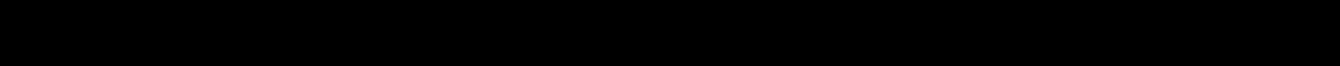
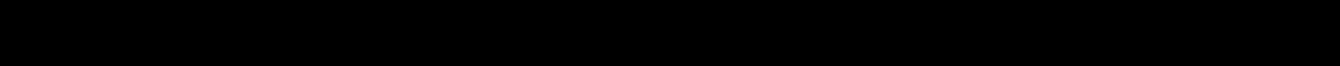
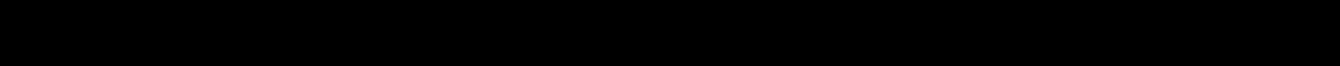
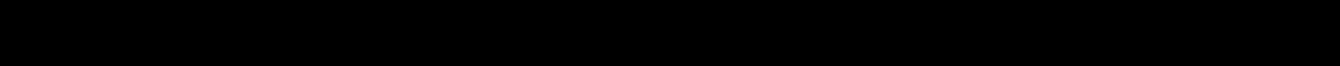

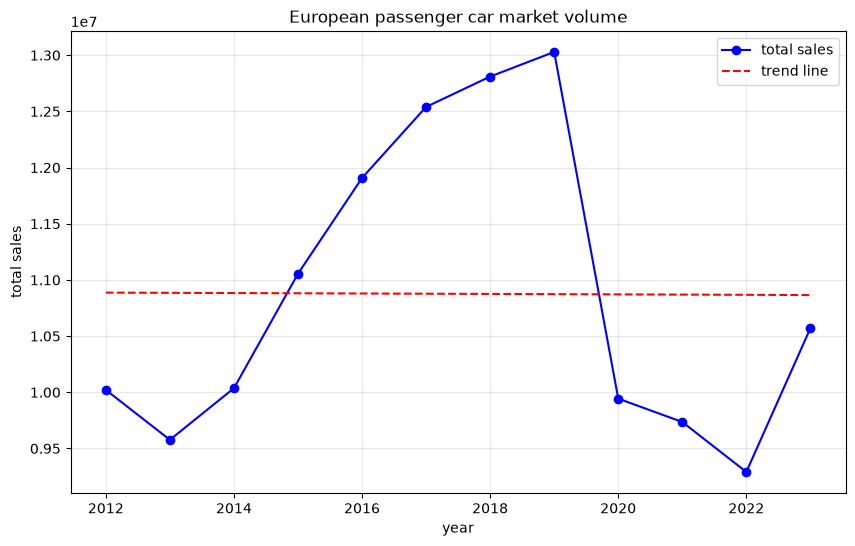

In [100]:
sales_by_year = df_market_segments.groupby("year")["sales_total"].sum()
x = sales_by_year.index.astype(float)
y = sales_by_year.values
m, b = np.polyfit(x, y, 1)
plt.figure(figsize=(10, 6))
plt.plot(x, y, marker='o', color='blue', label='total sales')
plt.plot(x, m * x + b, color='red', linestyle='--', label='trend line')
plt.xlabel("year")
plt.ylabel("total sales")
plt.title("European passenger car market volume")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Total passenger car sales increased until 2019, followed by a sharp decline in 2020–2022. This period coincides with the COVID-19 pandemic and the global disruptions to automotive supply chains. Despite substantial year-to-year fluctuations, the linear trend is almost flat, suggesting that total market volume remained relatively stable over the analyzed period. The market experienced considerable fluctuations rather than a steady upward or downward trend.

### 7.2 Top 10 bestselling models analysis

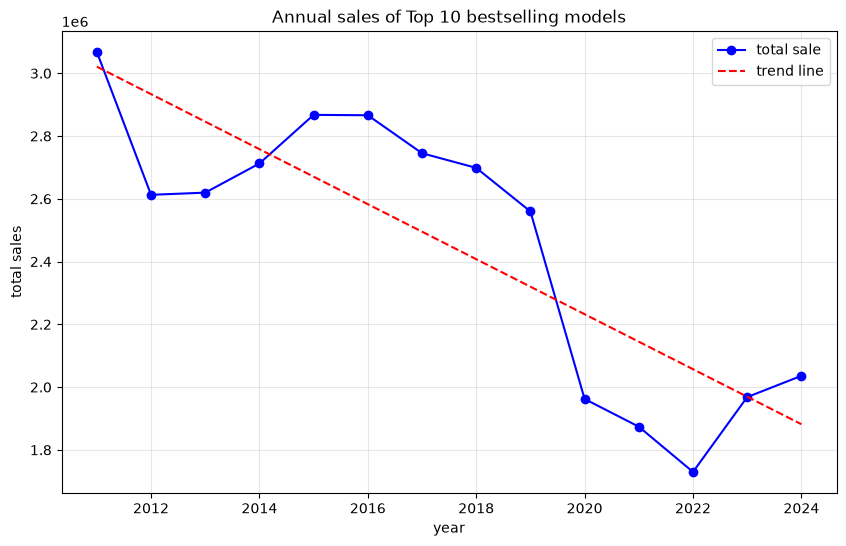

In [101]:
sales_by_year = df_top10.groupby("year")["sales"].sum()

x = sales_by_year.index.astype(float)
y = sales_by_year.values
m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(10, 6))
plt.plot(x, y, marker="o", color="blue", label="total sale")
plt.plot(x, m * x + b, color="red", linestyle="--", label="trend line")
plt.xlabel("year")
plt.ylabel("total sales")
plt.title("Annual sales of Top 10 bestselling models")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


The combined sales of the ten bestselling passenger car models declined over the analyzed period. This suggests that market leadership became less concentrated, although further analysis is required to determine whether this resulted from changing consumer preferences or overall market conditions.

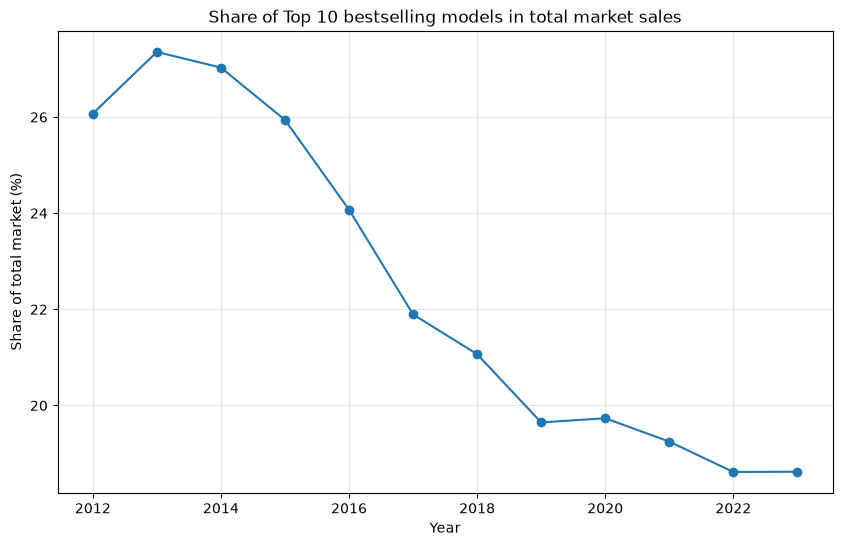

In [102]:
df_top10_comparable = df_top10[
    df_top10["year"].between(2012, 2023)
].copy()

top10_sales_by_year = (
    df_top10_comparable
    .groupby("year")["sales"]
    .sum()
)

total_sales_by_year = (
    df_market_segments
    .groupby("year")["sales_total"]
    .sum()
)

top10_market_share = (
    top10_sales_by_year
    / total_sales_by_year
    * 100
)



plt.figure(figsize=(10, 6))

plt.plot(
    top10_market_share.index,
    top10_market_share.values,
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Share of total market (%)")
plt.title("Share of Top 10 bestselling models in total market sales")
plt.grid(True, alpha=0.3)

plt.show()

Total Top 10 sales are declining not only because the size of the overall market is changing, but the Top 10 accounts for a decreasing share of total sales.

### 7.3 Analysis and visualization

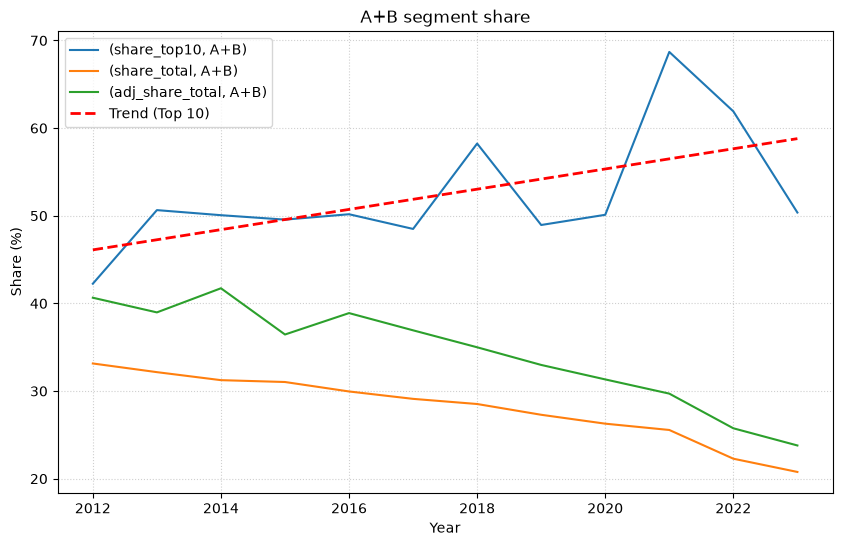

In [103]:
df_plot = (
    df_merged[df_merged["segment_group"] == "A+B"]
    .pivot(
        index="year",
        columns="segment_group",
        values=["share_top10", "share_total", "adj_share_total"]
    )
)

ax = df_plot.plot(figsize=(10, 6))

# Linia trendu dla share_top10
x = df_plot.index.astype(float)
y = df_plot[("share_top10", "A+B")].values

m, b = np.polyfit(x, y, 1)

ax.plot(
    x,
    m * x + b,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Trend (Top 10)"
)

plt.title("A+B segment share")
plt.xlabel("Year")
plt.ylabel("Share (%)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

plt.show()

The combined share of the A and B segments in overall sales is declining, but within the top ten best-selling cars, their combined share is growing. In 2021, there was a sharp increase in the share of these segments, but in subsequent years, there was a correction.

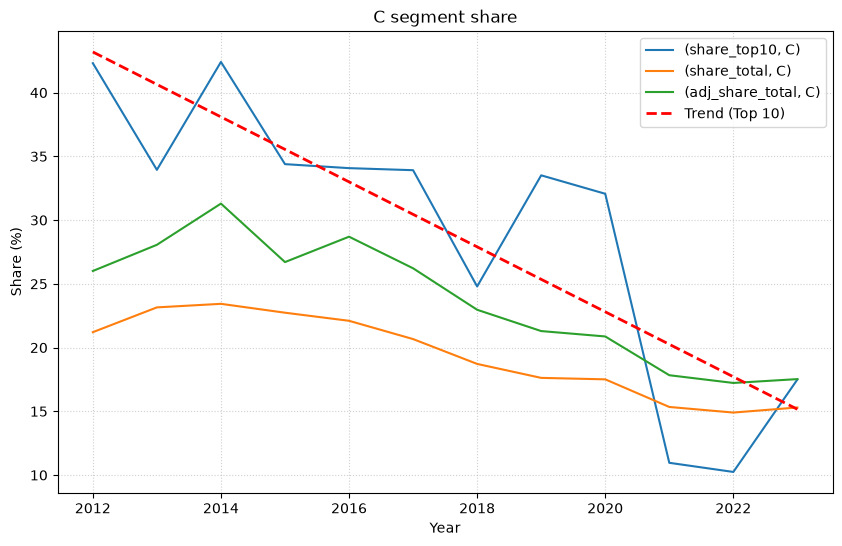

In [104]:
df_plot = (
    df_merged[df_merged["segment_group"] == "C"]
    .pivot(
        index="year",
        columns="segment_group",
        values=["share_top10", "share_total", "adj_share_total"]
    )
)

ax = df_plot.plot(figsize=(10, 6))

# Linia trendu dla share_top10
x = df_plot.index.astype(float)
y = df_plot[("share_top10", "C")].values

m, b = np.polyfit(x, y, 1)

ax.plot(
    x,
    m * x + b,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Trend (Top 10)"
)

plt.title("C segment share")
plt.xlabel("Year")
plt.ylabel("Share (%)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

plt.show()

The C segment lost market share both in the overall market and among the Top 10 bestselling models. The decline was much more pronounced within the Top 10, where the segment showed considerable year-to-year volatility before falling sharply after 2020. A partial recovery occurred in 2023, but the share remained well below its level at the beginning of the period.

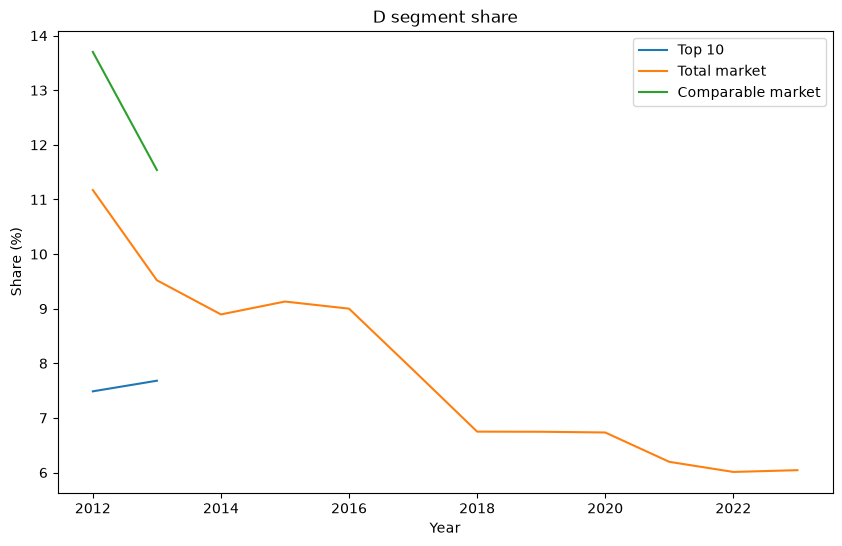

In [105]:
df_plot = (
    df_merged[df_merged["segment_group"] == "D"]
    .pivot(
        index="year",
        columns="segment_group",
        values=["share_top10", "share_total", "adj_share_total"]
    )
)

df_plot.columns = [
    "Top 10",
    "Total market",
    "Comparable market"
]

df_plot.plot(figsize=(10, 6))

plt.title("D segment share")
plt.xlabel("Year")
plt.ylabel("Share (%)")
plt.legend(title=None)

plt.show()

The D segment experienced a continuous decline in market share and was no longer represented among the Top 10 bestselling models after 2013, indicating a substantial reduction in its market importance.

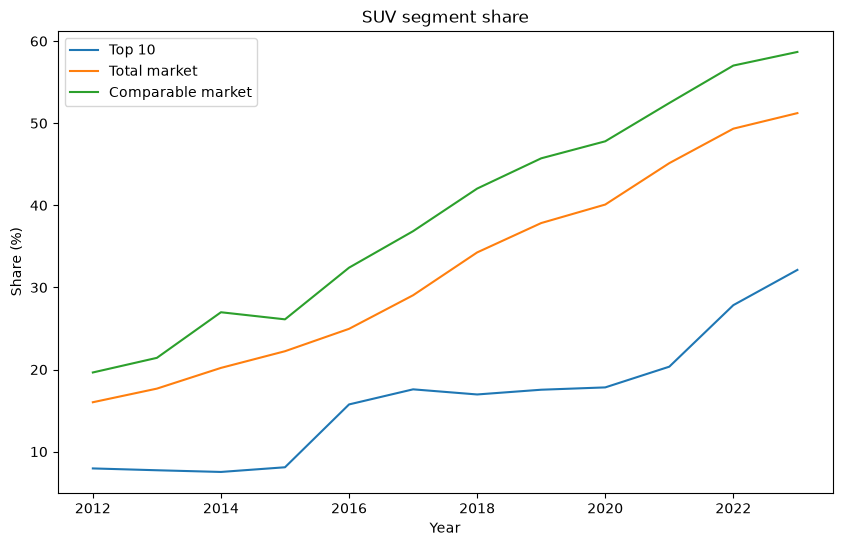

In [106]:

df_plot = (
    df_merged[df_merged["segment_group"] == "SUV"]
    .pivot(
        index="year",
        columns="segment_group",
        values=["share_top10", "share_total", "adj_share_total"]
    )
)

df_plot.columns = [
    "Top 10",
    "Total market",
    "Comparable market"
]

df_plot.plot(figsize=(10,6))
plt.title("SUV segment share")
plt.xlabel("Year")
plt.ylabel("Share (%)")
plt.show()

The SUV segment experienced the strongest growth during the analyzed period. Its share of the overall market increased from approximately 16% in 2012 to over 50% in 2023. The share of SUVs among the Top 10 bestselling models also increased substantially, but remained considerably lower than in the overall market. The difference cannot be explained solely by the absence of D, E+F and MPV segments from the Top 10. Even after adjusting the market structure to include only the segments represented in the Top 10 (adj_share_total), SUVs still account for a substantially larger share of the overall market than of the bestselling models.

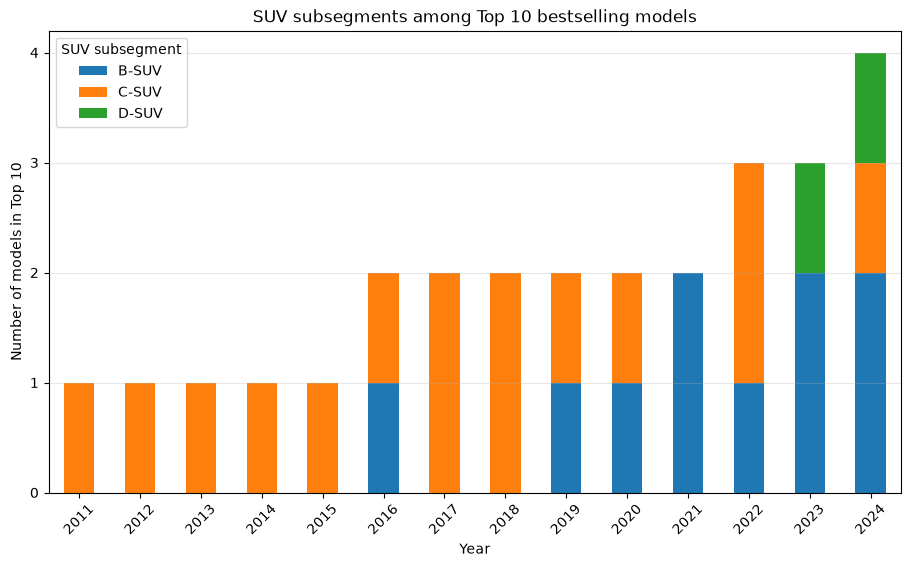

In [107]:
df_suv_count = (
    df_top10[
        df_top10["segment"].isin(["B-SUV", "C-SUV", "D-SUV"])
    ]
    .groupby(["year", "segment"])
    .size()
    .unstack(fill_value=0)
)

df_suv_count = df_suv_count.reindex(
    columns=["B-SUV", "C-SUV", "D-SUV"],
    fill_value=0
)


ax = df_suv_count.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)
ax.yaxis.set_major_locator(MultipleLocator(1))

plt.title("SUV subsegments among Top 10 bestselling models")
plt.xlabel("Year")
plt.ylabel("Number of models in Top 10")
plt.legend(title="SUV subsegment")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

The increasing presence of SUVs among the Top 10 bestselling models was accompanied by growing diversification across SUV size segments. Initially represented mainly by C-SUV models, SUVs later expanded to include B-SUV and D-SUV vehicles.

## 8. Conclusions


Overall passenger car sales fluctuated considerably during the analyzed period. Sales increased in the years preceding the COVID-19 pandemic and then declined sharply. Despite these fluctuations, the long-term sales trend remained relatively stable.

At the same time, both the absolute sales of the Top 10 bestselling models and their share of total market sales declined. This is particularly interesting in the context of the apparent reduction in model diversity observed in the European car market. Rather than becoming more concentrated around a small number of bestselling models, sales became increasingly distributed beyond the Top 10.

The composition of the Top 10 also changed substantially over time. The D segment, which was represented among the bestsellers at the beginning of the analyzed period, later disappeared from the ranking, while the niche E, F and MPV segments were absent throughout the analyzed period.

The combined A and B segments declined in the overall market but gradually increased their share among the Top 10 bestselling models. This suggests that models from these segments maintained a strong position among the market leaders despite their declining importance in the overall market. It should be noted, however, that their presence among the bestsellers was driven primarily by B-segment cars.

The C segment followed a similar long-term downward trend both in the overall market and among the Top 10 bestselling models, although year-to-year fluctuations were more pronounced among the bestsellers. It experienced the largest decline among the analyzed segments: while it dominated the Top 10 at the beginning of the period, by the end it had become the smallest segment represented among the bestsellers.

The most significant structural change was the rapid growth of SUVs. However, SUVs remained less dominant among the Top 10 bestselling models than in the overall market, even after adjusting the market structure to include only comparable vehicle segments. As SUVs became more prominent among the bestsellers, their representation also diversified across size categories: initially concentrated mainly in the C-SUV segment, they later expanded to include B-SUV and D-SUV models.

Overall, the analysis shows that changes among the Top 10 bestselling models reflect some of the major structural trends observed in the European passenger car market, but not necessarily their magnitude or timing. The Top 10 should therefore be viewed as an indicator of changes among market-leading models rather than as a direct representation of the structure of the overall market.

## 9. Limitations
The available data allow the identification of structural changes in the passenger car market but are insufficient to determine the underlying causes of these changes or to identify direct substitution between vehicle segments at the individual consumer level.

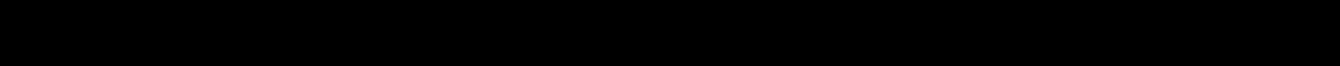
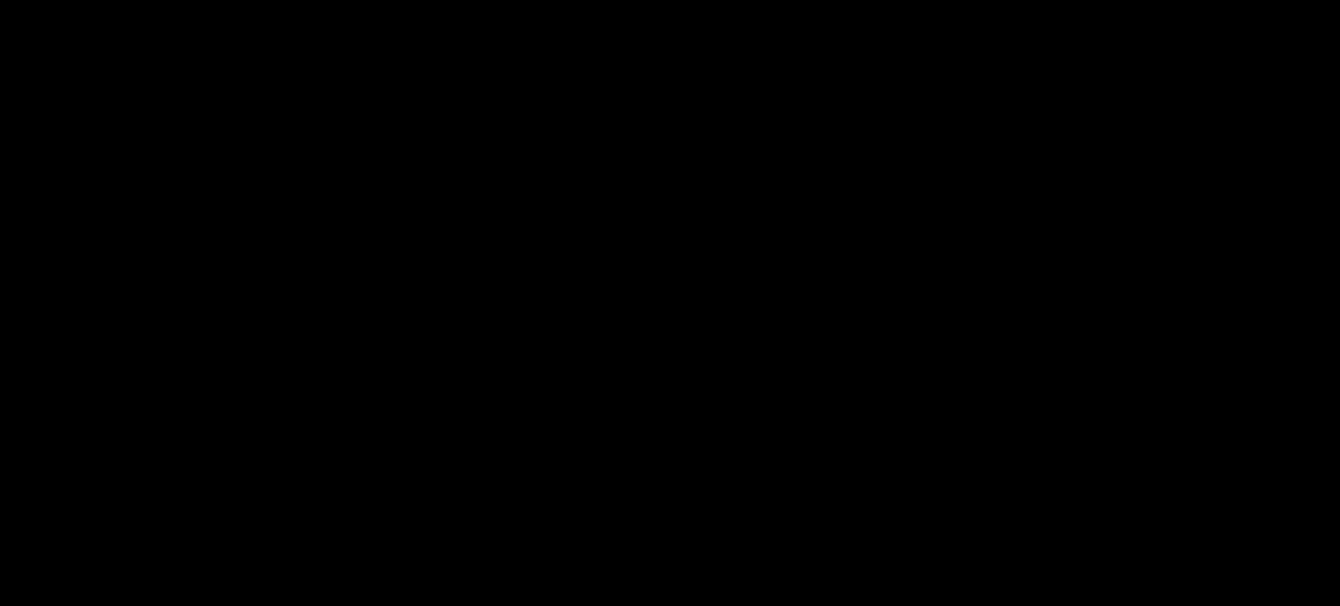
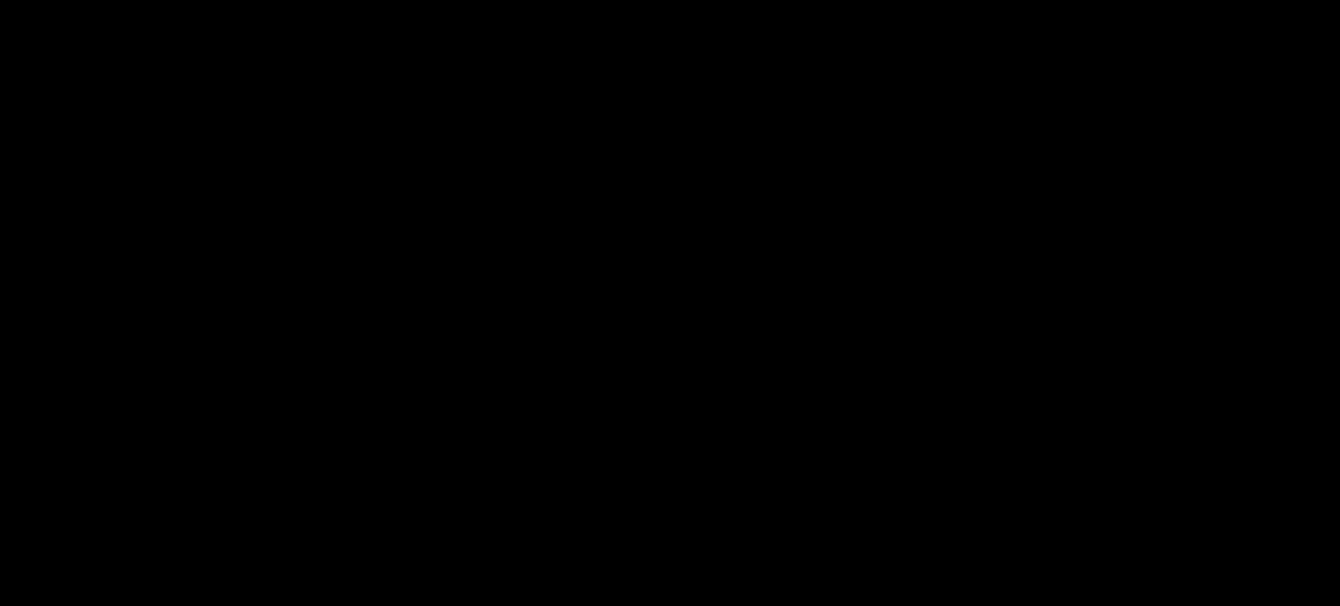